<a href="https://colab.research.google.com/github/DimiGretsistas/lab-control-flow-en/blob/master/Model_4(55%25).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Working with a new dataset: CIFAR-10**

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. More information about CIFAR-10 can be found [here](https://www.cs.toronto.edu/~kriz/cifar.html).

In Keras, the CIFAR-10 dataset is also preloaded in the form of four Numpy arrays. x_train and y_train contain the training set, while x_test and y_test contain the test data. The images are encoded as Numpy arrays and their corresponding labels ranging from 0 to 9.




In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

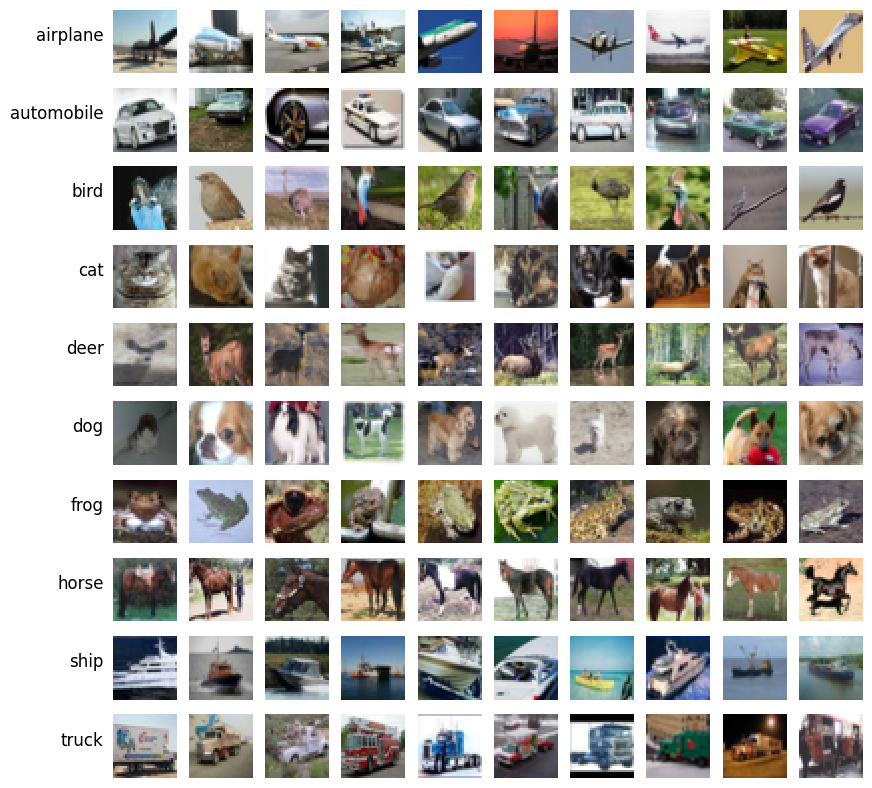

In [ ]:
# Class names
classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

# Create 10x10 grid
plt.figure(figsize=(10,10))

for class_idx in range(10):
  # Get indices of this class (finds images of a specific class)
  idx = np.where(y_train.flatten() == class_idx)[0]

  # Pick 10 random samples
  random_idx = np.random.choice(idx, 10, replace=False)

  for i, idx in enumerate(random_idx):
    plt_idx = class_idx * 10 + i + 1
    plt.subplot(10, 10, plt_idx)
    plt.imshow(x_train[idx])
    plt.axis('off')

    # Show class name clearly on the left
    if i == 0:
      plt.text(-5, 15, classes[class_idx], fontsize=12, ha='right')

plt.subplots_adjust(left=0.15)  # creates space so labels aren’t cut off
plt.show()

# Convert the labels to one-hot encoded form.
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Normalize the images
x_train_normalized = x_train.astype('float32') / 255.0
x_test_normalized = x_test.astype('float32') / 255.0

In [ ]:
from keras.backend import clear_session
clear_session()

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization
from keras import optimizers

model4 = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),

    Flatten(),
    Dense(10, activation='relu'),
    BatchNormalization(),
    Dense(10, activation='softmax')
])

model4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        10,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,360 (263.12 KB)

 Trainable params: 67,020 (261.80 KB)

 Non-trainable params: 340 (1.33 KB)

In [ ]:
rms = optimizers.RMSprop(learning_rate=0.001)

# Compile the model
model4.compile(
    loss='categorical_crossentropy',
    optimizer=rms,
    metrics=['accuracy']
)

# Train the model
history = model4.fit(
    x_train_normalized,
    y_train,
    epochs=50,
    batch_size=512,
    validation_split=0.2,
)

Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - accuracy: 0.4281 - loss: 1.6851 - val_accuracy: 0.0997 - val_loss: 2.7400
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5660 - loss: 1.3089 - val_accuracy: 0.1588 - val_loss: 2.7729
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6283 - loss: 1.1116 - val_accuracy: 0.1221 - val_loss: 2.8856
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6727 - loss: 0.9771 - val_accuracy: 0.2482 - val_loss: 2.5197
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7031 - loss: 0.8778 - val_accuracy: 0.2987 - val_loss: 2.2037
Epoch 6/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7261 - loss: 0.8020 - val_accuracy: 0.3660 - val_loss: 2.0439
Epoch 7/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7470 - loss: 0.7362 - val_accuracy: 0.5079 - val_loss: 1.4596
Epoch 8/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7675 - loss: 0.6818 - val_accuracy: 0.5492 - v

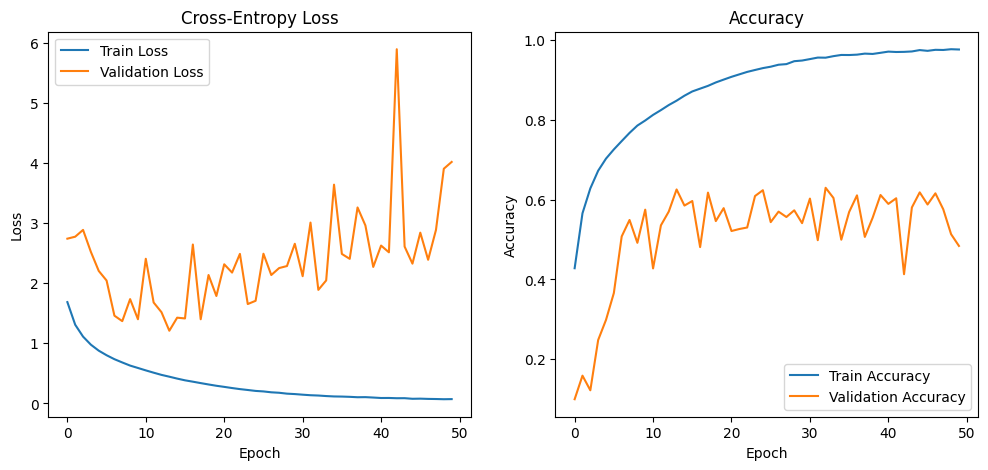

In [ ]:
plt.figure(figsize=(12,5))

# Loss plot
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Cross-Entropy Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
test_loss, test_accuracy = model4.evaluate(x_test_normalized, y_test)

print("Test Accuracy for base model:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4843 - loss: 4.1119
Test Accuracy for base model: 0.48429998755455017


In [ ]:
# Save model
model4.save("model4.keras")